In [1]:
import subprocess
subprocess.run(["pip", "install", "ultralytics", "-q"], check=True)
print("ultralytics installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
ultralytics installed


In [11]:
import os, json, pickle, shutil, random
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
 
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


In [12]:
DATA_ROOT     = Path("/kaggle/input/datasets/sahilakolte/vr-project-1/dataset/processed")
TRAIN_IMG_DIR = DATA_ROOT / "train"      / "images"
TRAIN_ANN_DIR = DATA_ROOT / "train"      / "annos"
VAL_IMG_DIR   = DATA_ROOT / "validation" / "images"
VAL_ANN_DIR   = DATA_ROOT / "validation" / "annos"
YOLO_DIR      = Path("/kaggle/working/yolo_dataset")
OUT_DIR       = Path("/kaggle/working/yolo_scratch")
OUT_DIR.mkdir(parents=True, exist_ok=True)
 

Load metadata

In [13]:
with open(DATA_ROOT / "top5.pkl", "rb") as f:
    top5_data = pickle.load(f)
with open(DATA_ROOT / "label_map.pkl", "rb") as f:
    label_map = pickle.load(f)
with open(DATA_ROOT / "train_labels.pkl", "rb") as f:
    train_labels = pickle.load(f)
with open(DATA_ROOT / "val_labels.pkl", "rb") as f:
    val_labels = pickle.load(f)
 
ALL_CATEGORIES = {
    1:"short_sleeve_top",    2:"long_sleeve_top",
    3:"short_sleeve_outwear",4:"long_sleeve_outwear",
    5:"vest",                6:"sling",
    7:"shorts",              8:"trousers",
    9:"skirt",               10:"short_sleeve_dress",
    11:"long_sleeve_dress",  12:"vest_dress",
    13:"sling_dress"
}
CLASS_NAMES = [ALL_CATEGORIES[cat_id] for cat_id in top5_data]
NUM_CLASSES  = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"label_map: {label_map}")

Classes (5): ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']
label_map: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


Stratified sampling on train

In [14]:
def stratified_sample_yolo(labels_dict, img_dir, fraction=0.3,
                            num_classes=5, min_per_class=500, seed=42):
    """
    labels_dict : {"filename.jpg": np.array([0,1,0,0,1])}
    Returns     : sampled dict with same format
    """
    random.seed(seed)
 
    # Build class buckets
    class_buckets = {i: [] for i in range(num_classes)}
    for filename, label_arr in labels_dict.items():
        img_path = img_dir / filename
        if not img_path.exists():
            continue
        for i, v in enumerate(label_arr):
            if v == 1.0:
                class_buckets[i].append(filename)
 
    print("Class distribution BEFORE sampling:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  [{i}] {name:<28s}: {len(class_buckets[i])}")
 
    sampled_keys = set()
    for i in range(num_classes):
        bucket = class_buckets[i]
        n      = max(min_per_class, int(len(bucket) * fraction))
        chosen = random.sample(bucket, min(n, len(bucket)))
        sampled_keys.update(chosen)
 
    sampled_dict = {k: labels_dict[k] for k in sampled_keys if k in labels_dict}
 
    print(f"\nAfter sampling: {len(sampled_dict)}/{len(labels_dict)} "
          f"({len(sampled_dict)/len(labels_dict)*100:.1f}%)")
    print("Class distribution AFTER sampling:")
    for i, name in enumerate(CLASS_NAMES):
        count = sum(1 for arr in sampled_dict.values() if arr[i] == 1.0)
        print(f"  [{i}] {name:<28s}: {count}")
    return sampled_dict
 
train_labels_sampled = stratified_sample_yolo(
    train_labels, TRAIN_IMG_DIR,
    fraction=0.15, num_classes=NUM_CLASSES, min_per_class=500
)
 
# Val/test split
val_keys  = list(val_labels.keys())
random.shuffle(val_keys)
mid       = len(val_keys) // 2
test_keys = val_keys[mid:]
val_keys  = val_keys[:mid]
test_labels = {k: val_labels[k] for k in test_keys}
val_labels  = {k: val_labels[k] for k in val_keys}
print(f"\nTrain:{len(train_labels_sampled)}  Val:{len(val_labels)}  Test:{len(test_labels)}")


Class distribution BEFORE sampling:
  [0] short_sleeve_top            : 70586
  [1] trousers                    : 54969
  [2] shorts                      : 36332
  [3] long_sleeve_top             : 35751
  [4] skirt                       : 30625

After sampling: 32244/144174 (22.4%)
Class distribution AFTER sampling:
  [0] short_sleeve_top            : 17629
  [1] trousers                    : 13015
  [2] shorts                      : 8737
  [3] long_sleeve_top             : 9029
  [4] skirt                       : 7552

Train:32244  Val:11870  Test:11871


Build YOLO dataset

In [15]:
for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)
 
def polygon_to_yolo(polygons, img_w, img_h):
    for poly in polygons:
        if len(poly) >= 6:
            pts = []
            for i in range(0, len(poly) - 1, 2):
                pts.append(max(0.0, min(1.0, poly[i]   / img_w)))
                pts.append(max(0.0, min(1.0, poly[i+1] / img_h)))
            if len(pts) >= 6:
                return pts
    return None
 
def bbox_fallback(bbox, img_w, img_h):
    x1, y1, x2, y2 = bbox
    c = [x1/img_w, y1/img_h, x2/img_w, y1/img_h,
          x2/img_w, y2/img_h, x1/img_w, y2/img_h]
    return [max(0.0, min(1.0, v)) for v in c]
 
def write_yolo_split(labels_dict, img_dir, ann_dir, split_name):
    img_out = YOLO_DIR / "images" / split_name
    lbl_out = YOLO_DIR / "labels" / split_name
    written = 0
    for filename in tqdm(labels_dict.keys(), desc=f"Build {split_name}"):
        img_path = img_dir / filename
        if not img_path.exists():
            continue
        try:
            with Image.open(img_path) as im:
                img_w, img_h = im.size
        except Exception:
            continue
        stem     = Path(filename).stem
        ann_path = ann_dir / (stem + ".json")
        lines    = []
        if ann_path.exists():
            try:
                with open(ann_path) as f:
                    ann = json.load(f)
                for key in ann:
                    if not key.startswith("item"): continue
                    item   = ann[key]
                    cat_id = item.get("category_id")
                    if cat_id not in label_map: continue
                    label = label_map[cat_id]
                    pts   = (polygon_to_yolo(item.get("segmentation", []), img_w, img_h)
                             or bbox_fallback(item.get("bounding_box", [0,0,img_w,img_h]), img_w, img_h))
                    lines.append(f"{label} " + " ".join(f"{v:.6f}" for v in pts))
            except Exception:
                pass
        if not lines: continue
        dst = img_out / filename
        if not dst.exists():
            try: os.symlink(img_path.resolve(), dst)
            except Exception: shutil.copy2(img_path, dst)
        with open(lbl_out / (stem + ".txt"), "w") as f:
            f.write("\n".join(lines))
        written += 1
    print(f"  {split_name}: {written} images written")
 
print("\nBuilding YOLO dataset...")
write_yolo_split(train_labels_sampled, TRAIN_IMG_DIR, TRAIN_ANN_DIR, "train")
write_yolo_split(val_labels,           VAL_IMG_DIR,   VAL_ANN_DIR,   "val")
write_yolo_split(test_labels,          VAL_IMG_DIR,   VAL_ANN_DIR,   "test")



Building YOLO dataset...


Build train: 100%|██████████| 32244/32244 [10:19<00:00, 52.04it/s]


  train: 32244 images written


Build val: 100%|██████████| 11870/11870 [04:24<00:00, 44.94it/s]


  val: 11870 images written


Build test: 100%|██████████| 11871/11871 [04:22<00:00, 45.14it/s]

  test: 11871 images written


data.yaml

In [17]:
yaml_path = YOLO_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    f.write(f"path: {YOLO_DIR}\n"
            f"train: images/train\n"
            f"val: images/val\n"
            f"test: images/test\n"
            f"nc: {NUM_CLASSES}\n"
            f"names: {CLASS_NAMES}\n")
print(f"data.yaml:\n{yaml_path.read_text()}")
 
# Label distribution
counter = {i: 0 for i in range(NUM_CLASSES)}
for lf in (YOLO_DIR / "labels" / "train").glob("*.txt"):
    for line in open(lf):
        cls = int(line.split()[0])
        counter[cls] = counter.get(cls, 0) + 1
print("Train label distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name:<28s}: {counter.get(i,0)}")


data.yaml:
path: /kaggle/working/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 5
names: ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']

Train label distribution:
  [0] short_sleeve_top            : 17910
  [1] trousers                    : 13116
  [2] shorts                      : 8817
  [3] long_sleeve_top             : 9122
  [4] skirt                       : 7601


Train YOLO FROM SCRATCH

In [19]:
print("\n" + "="*55)
print("YOLO TRAINING FROM SCRATCH")
print("="*55)
 
model = YOLO("yolov8n-seg.yaml")   # no pretrained weights
 
results = model.train(
    data         = str(yaml_path),
    epochs       = 20,             
    imgsz        = 640,
    batch        = 8,              
    device       = device,
    project      = str(OUT_DIR),
    name         = "train",
    optimizer    = "Adam",
    lr0          = 1e-3,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 5e-4,
    warmup_epochs= 3,
    cos_lr       = True,
    patience     = 10,             # early stopping
    cls          = 0.5,
    box          = 7.5,
    dfl          = 1.5,
    flipud       = 0.2,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    degrees      = 10,
    translate    = 0.1,
    scale        = 0.5,
    plots        = True,
    save         = True,
    verbose      = True,
    seed         = SEED,
    workers      = 2,
)
print("Training complete!")



YOLO TRAINING FROM SCRATCH
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n-seg.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overl

Validate

In [22]:
best_weights = OUT_DIR / "train3" / "weights" / "best.pt"
model_best   = YOLO(str(best_weights))
 
val_results = model_best.val(
    data=str(yaml_path), split="val",
    imgsz=640, batch=8, device=device, plots=True, verbose=True,
)
print(f"\nmAP@0.5      (seg): {val_results.seg.map50:.4f}")
print(f"mAP@0.5:0.95 (seg): {val_results.seg.map:.4f}")
print(f"mAP@0.5      (box): {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95 (box): {val_results.box.map:.4f}")

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,039 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 79.6±10.0 MB/s, size: 43.8 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 11870 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11870/11870 5.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1484/1484 13.5it/s 1:50<0.1s
                   all      11870      19391      0.793      0.782      0.828      0.665      0.789      0.775      0.818      0.615
      short_sleeve_top       6269       6346      0.831       0.88      0.925      0.803      0.831      0.878      0.923      0.743
              trousers       4750       4795      0.821      0.849      0.852      0.656      0.804      0.829      0.826      0.576
                shorts

mIoU and Dice

In [23]:
print("\nComputing mIoU and Dice...")
try:
    import cv2
    IMG_SIZE      = 640
    inter_sum     = np.zeros(NUM_CLASSES)
    union_sum     = np.zeros(NUM_CLASSES)
    pred_sum      = np.zeros(NUM_CLASSES)
    gt_sum        = np.zeros(NUM_CLASSES)
    val_imgs      = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:300]
    if not val_imgs:
        val_imgs  = sorted((YOLO_DIR / "images" / "val").glob("*.png"))[:300]
 
    for img_path in tqdm(val_imgs, desc="mIoU/Dice"):
        stem     = img_path.stem
        lbl_path = YOLO_DIR / "labels" / "val" / (stem + ".txt")
        if not lbl_path.exists(): continue
        gt_masks = {c: np.zeros((IMG_SIZE, IMG_SIZE), np.uint8) for c in range(NUM_CLASSES)}
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7: continue
                cls = int(parts[0])
                pts = np.array(parts[1:], float).reshape(-1, 2)
                pts[:, 0] *= IMG_SIZE; pts[:, 1] *= IMG_SIZE
                cv2.fillPoly(gt_masks[cls], [pts.astype(np.int32)], 1)
        preds = model_best.predict(str(img_path), imgsz=IMG_SIZE, verbose=False, device=device)
        pred_masks = {c: np.zeros((IMG_SIZE, IMG_SIZE), np.uint8) for c in range(NUM_CLASSES)}
        if preds and preds[0].masks is not None:
            for mask, cls in zip(preds[0].masks.data.cpu().numpy(),
                                  preds[0].boxes.cls.cpu().numpy().astype(int)):
                if cls < NUM_CLASSES:
                    m = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
                    pred_masks[cls] = np.clip(pred_masks[cls] + (m > 0.5), 0, 1).astype(np.uint8)
        for c in range(NUM_CLASSES):
            inter_sum[c] += (pred_masks[c] & gt_masks[c]).sum()
            union_sum[c] += (pred_masks[c] | gt_masks[c]).sum()
            pred_sum[c]  += pred_masks[c].sum()
            gt_sum[c]    += gt_masks[c].sum()
 
    iou_arr  = inter_sum / (union_sum + 1e-6)
    dice_arr = (2 * inter_sum) / (pred_sum + gt_sum + 1e-6)
    print(f"\nPer-class — YOLO (Scratch):")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  [{i}] {name:<28s}: IoU={iou_arr[i]:.4f}  Dice={dice_arr[i]:.4f}")
    print(f"  Mean IoU : {iou_arr.mean():.4f}")
    print(f"  Mean Dice: {dice_arr.mean():.4f}")
except ImportError:
    print("cv2 not found — skipping mIoU/Dice")
    iou_arr = dice_arr = np.zeros(NUM_CLASSES)



Computing mIoU and Dice...


mIoU/Dice: 100%|██████████| 300/300 [00:07<00:00, 39.17it/s]


Per-class — YOLO (Scratch):
  [0] short_sleeve_top            : IoU=0.5813  Dice=0.7352
  [1] trousers                    : IoU=0.5177  Dice=0.6822
  [2] shorts                      : IoU=0.2385  Dice=0.3852
  [3] long_sleeve_top             : IoU=0.3839  Dice=0.5548
  [4] skirt                       : IoU=0.5988  Dice=0.7491
  Mean IoU : 0.4640
  Mean Dice: 0.6213


Detection ROC / AUC / F1


Computing detection ROC/AUC/F1...


Det metrics: 100%|██████████| 300/300 [00:03<00:00, 75.00it/s]


Detection F1 — Macro:0.7066  Micro:0.7417


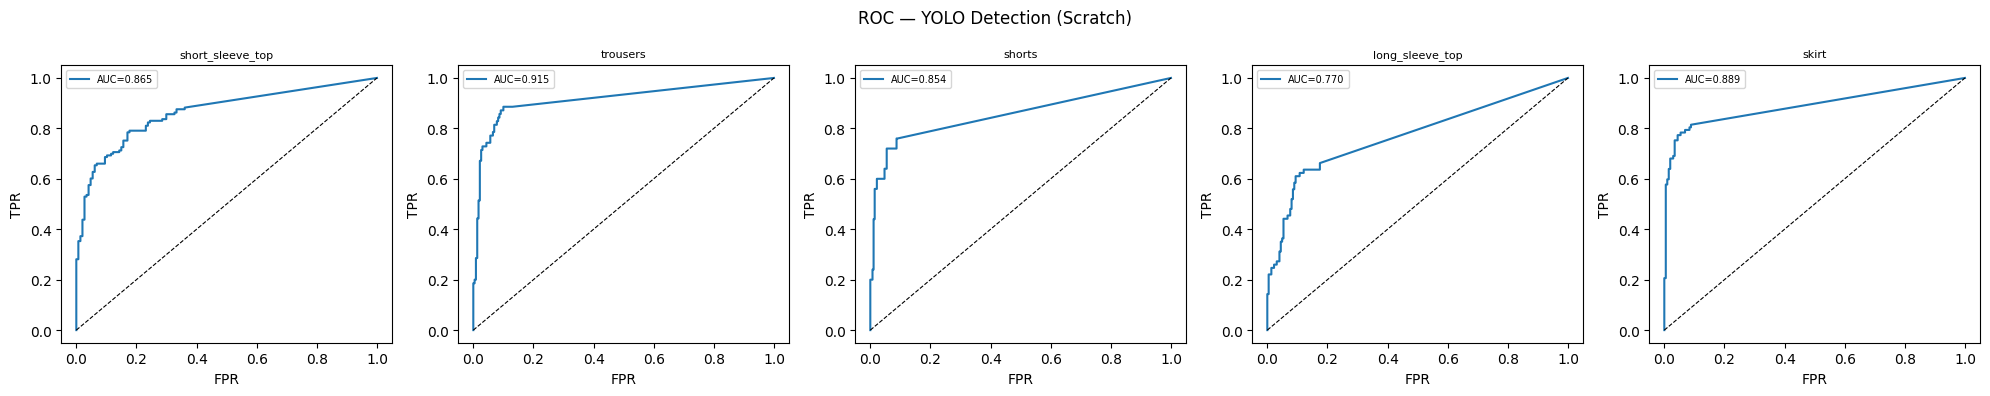

In [24]:
print("\nComputing detection ROC/AUC/F1...")
val_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:300]
if not val_imgs:
    val_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.png"))[:300]
 
y_true, y_scores = [], []
for img_path in tqdm(val_imgs, desc="Det metrics"):
    stem     = img_path.stem
    lbl_path = YOLO_DIR / "labels" / "val" / (stem + ".txt")
    gt_vec   = np.zeros(NUM_CLASSES)
    if lbl_path.exists():
        for line in open(lbl_path):
            cls = int(line.split()[0])
            if cls < NUM_CLASSES: gt_vec[cls] = 1
    try:
        preds     = model_best.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=device)
        score_vec = np.zeros(NUM_CLASSES)
        if preds and preds[0].boxes is not None:
            for cls, conf in zip(preds[0].boxes.cls.cpu().numpy().astype(int),
                                  preds[0].boxes.conf.cpu().numpy()):
                if cls < NUM_CLASSES:
                    score_vec[cls] = max(score_vec[cls], float(conf))
    except Exception:
        score_vec = np.zeros(NUM_CLASSES)
    y_true.append(gt_vec); y_scores.append(score_vec)
 
y_true   = np.array(y_true)
y_scores = np.array(y_scores)
y_pred   = (y_scores >= 0.25).astype(int)
det_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
det_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
print(f"Detection F1 — Macro:{det_macro:.4f}  Micro:{det_micro:.4f}")
 
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4*NUM_CLASSES, 4))
auc_scores = []
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        auc = roc_auc_score(y_true[:, i], y_scores[:, i])
        auc_scores.append(auc); axes[i].plot(fpr, tpr, label=f"AUC={auc:.3f}")
    except Exception:
        auc_scores.append(0.0); axes[i].text(0.5, 0.5, "N/A", ha="center")
    axes[i].plot([0,1],[0,1],"k--",lw=0.8)
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("FPR"); axes[i].set_ylabel("TPR")
    axes[i].legend(fontsize=7)
plt.suptitle("ROC — YOLO Detection (Scratch)")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_curves.png", dpi=100)
plt.show()


Save results

In [25]:
results_summary = {
    "model": "YOLOv8n-seg", "training": "from_scratch",
    "map50_seg": float(val_results.seg.map50), "map_seg": float(val_results.seg.map),
    "map50_box": float(val_results.box.map50), "map_box": float(val_results.box.map),
    "mean_mIoU": float(iou_arr.mean()),        "mean_dice": float(dice_arr.mean()),
    "iou_per_class": iou_arr.tolist(),         "dice_per_class": dice_arr.tolist(),
    "det_f1_macro": det_macro,                 "det_f1_micro": det_micro,
    "auc_per_class": auc_scores,               "class_names": CLASS_NAMES,
}
with open(OUT_DIR / "results.pkl", "wb") as f:
    pickle.dump(results_summary, f)
 
print(f"\n{'='*55}")
print("YOLO SCRATCH — FINAL SUMMARY")
print(f"{'='*55}")
print(f"mAP@0.5      (seg): {val_results.seg.map50:.4f}")
print(f"mAP@0.5:0.95 (seg): {val_results.seg.map:.4f}")
print(f"Mean mIoU         : {iou_arr.mean():.4f}")
print(f"Mean Dice         : {dice_arr.mean():.4f}")
print(f"Det F1 (macro)    : {det_macro:.4f}")
print(f"Best weights      : {best_weights}")
print(f"All outputs       : {OUT_DIR}")



YOLO SCRATCH — FINAL SUMMARY
mAP@0.5      (seg): 0.8182
mAP@0.5:0.95 (seg): 0.6150
Mean mIoU         : 0.4640
Mean Dice         : 0.6213
Det F1 (macro)    : 0.7066
Best weights      : /kaggle/working/yolo_scratch/train3/weights/best.pt
All outputs       : /kaggle/working/yolo_scratch



0: 640x480 1 short_sleeve_top, 8.7ms
Speed: 2.0ms preprocess, 8.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


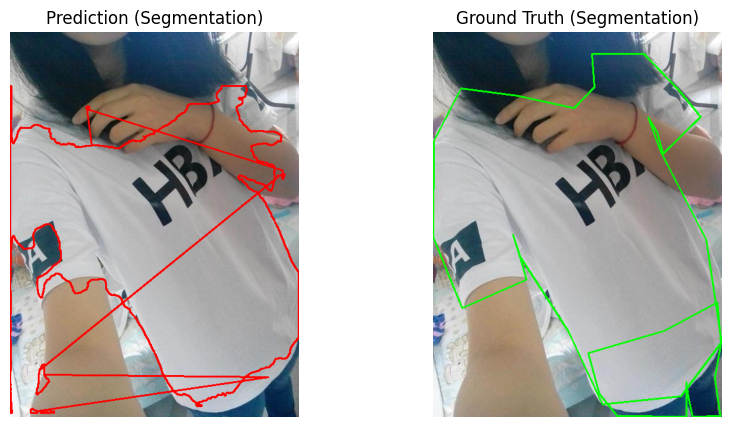


0: 640x448 2 short_sleeve_tops, 8.6ms
Speed: 2.1ms preprocess, 8.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 448)


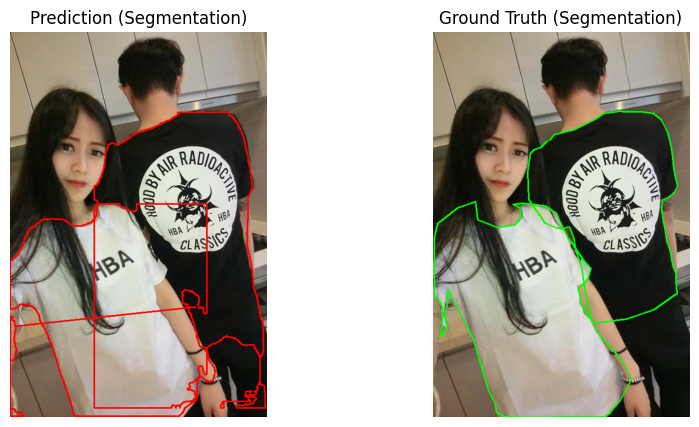

In [26]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt


IMAGE_DIR = "/kaggle/input/datasets/sahilakolte/vr-project-1/hidden_dataset/hidden_dataset/images"
ANNO_DIR  = "/kaggle/input/datasets/sahilakolte/vr-project-1/hidden_dataset/hidden_dataset/annos"

NUM_IMAGES = 10
image_files = sorted(os.listdir(IMAGE_DIR))[:NUM_IMAGES]

for img_name in image_files:

    img_path = os.path.join(IMAGE_DIR, img_name)
    json_path = os.path.join(ANNO_DIR, img_name.replace(".jpg", ".json"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # -------------------------
    # MODEL PREDICTION (SEGMENTATION)
    # -------------------------
    results = model(img)   # YOLOv8 segmentation model

    pred_img = img.copy()

    for r in results:
        if r.masks is not None:
            for mask in r.masks.xy:     # polygon points
                pts = np.array(mask, dtype=np.int32)
                cv2.polylines(pred_img, [pts], True, (255,0,0), 2)   # blue = prediction

    # -------------------------
    # GROUND TRUTH (from JSON)
    # -------------------------
    gt_img = img.copy()

    with open(json_path) as f:
        data = json.load(f)

    for key in ["item1", "item2"]:   # your json contains 2 objects
        if key in data:
            seg = data[key]["segmentation"][0]

            pts = np.array(seg).reshape(-1,2).astype(np.int32)
            cv2.polylines(gt_img, [pts], True, (0,255,0), 2)  # green = ground truth

    # -------------------------
    # SHOW RESULT
    # -------------------------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Prediction (Segmentation)")
    plt.imshow(pred_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ground Truth (Segmentation)")
    plt.imshow(gt_img)
    plt.axis("off")

    plt.show()